# Student Depression Risk Prediction Using Machine Learning

## Project Overview

Mental health among students has become an increasingly important issue across educational institutions worldwide. This project uses machine learning techniques to identify students who may be at risk of depression based on demographic, academic, lifestyle, and family-related factors.

The project demonstrates the complete data science workflow, from data preprocessing and exploratory analysis to predictive modelling and deployment of a simple risk assessment system.

---

**Tools Used**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

---

**Models Used**

- Logistic Regression
- Random Forest Classifier

## Importing Required Libraries

This section imports all the libraries required throughout the project.

Each library serves a specific purpose:

- Pandas and NumPy for data manipulation.
- Matplotlib and Seaborn for visualization.
- SciPy for statistical analysis.
- Scikit-learn for building and evaluating machine learning models.m

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

## Loading the Dataset

The dataset is imported into a Pandas DataFrame.

After loading the data, we inspect its dimensions, data types, and the first few observations to understand its overall structure before any preprocessing begins.

In [2]:
df = pd.read_csv(r"C:\Users\KHENNYG\Downloads\DATA ANALYSIS CLASS\Student Depression Dataset.csv")
df.shape       
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


# 3. Exploring Individual Variables

Before cleaning the data, it is useful to understand the distribution of important variables.

The Financial Stress variable is examined first because it is expected to have a strong relationship with student depression.

In [3]:
df['Financial Stress'].value_counts()

Financial Stress
5.0    6715
4.0    5775
3.0    5226
1.0    5121
2.0    5061
Name: count, dtype: int64

## Exploring Categorical Variables

Categorical variables cannot be used directly by most machine learning algorithms.

This section identifies the unique categories present within each variable before they are encoded.

In [4]:
# Look at your categorical columns before encoding
for col in ['Gender', 'Sleep Duration', 'Dietary Habits', 'Family History of Mental Illness']:
    print(col, df[col].unique())

Gender ['Male' 'Female']
Sleep Duration ['5-6 hours' 'Less than 5 hours' '7-8 hours' 'More than 8 hours' 'Others']
Dietary Habits ['Healthy' 'Moderate' 'Unhealthy' 'Others']
Family History of Mental Illness ['No' 'Yes']


# 4. Feature Engineering

Machine learning algorithms require numerical inputs.

The categorical variables are therefore converted into numerical representations.

Binary variables are encoded as 0 and 1, while ordinal variables preserve their natural ordering.

In [5]:
# Binary nominal encodings
df['Gender_enc'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['FamilyHistory_enc'] = df['Family History of Mental Illness'].map({'No': 0, 'Yes': 1})
df['Suicidal_enc'] = df['Have you ever had suicidal thoughts ?'].map({'No': 0, 'Yes': 1})

# Ordinal encodings
sleep_map = {'Less than 5 hours': 1, '5-6 hours': 2, '7-8 hours': 3,
             'More than 8 hours': 4, 'Others': np.nan}
df['Sleep_Ordinal'] = df['Sleep Duration'].map(sleep_map)

diet_map = {'Unhealthy': 1, 'Moderate': 2, 'Healthy': 3, 'Others': np.nan}
df['Dietary_enc'] = df['Dietary Habits'].map(diet_map)

# 5. Data Cleaning

Missing values can negatively affect statistical analysis and predictive models.

Median imputation is used to replace missing values because it is less sensitive to extreme values than the mean.

In [6]:
df['Financial Stress'] = df['Financial Stress'].fillna(df['Financial Stress'].median())
df['Sleep_Ordinal'] = df['Sleep_Ordinal'].fillna(df['Sleep_Ordinal'].median())
df['Dietary_enc'] = df['Dietary_enc'].fillna(df['Dietary_enc'].median())

# 6. Statistical Analysis

Before training machine learning models, statistical tests are used to examine relationships between predictor variables and the target variable.

This notebook applies:

- Point-Biserial Correlation for numerical variables
- Cramér's V for categorical variables

In [7]:
# Point-biserial for numeric predictors
numeric_cols = ['Age', 'Academic Pressure', 'Work/Study Hours',
                 'Financial Stress', 'Study Satisfaction', 'Sleep_Ordinal', 'Dietary_enc']

for col in numeric_cols:
    r, p = pointbiserialr(df[col], df['Depression'])
    print(f"{col:25s} r={r:.3f}  p={p:.4f}")

# Cramér's V for categorical predictors
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

for col in ['Gender', 'Dietary Habits', 'Family History of Mental Illness', 'Sleep Duration']:
    print(col, round(cramers_v(df[col], df['Depression']), 3))

Age                       r=-0.226  p=0.0000
Academic Pressure         r=0.475  p=0.0000
Work/Study Hours          r=0.209  p=0.0000
Financial Stress          r=0.364  p=0.0000
Study Satisfaction        r=-0.168  p=0.0000
Sleep_Ordinal             r=-0.087  p=0.0000
Dietary_enc               r=-0.207  p=0.0000
Gender 0.002
Dietary Habits 0.208
Family History of Mental Illness 0.053
Sleep Duration 0.1


### Interpretation

Variables with stronger statistical relationships may contribute more to predicting depression.

These findings also help justify the selection of predictor variables for machine learning.

# 7. Correlation Analysis

A correlation heatmap is created to visualise relationships among numerical variables.

This helps identify variables that move together and provides insight into possible multicollinearity.

In [8]:
df.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
Gender_enc                               0
FamilyHistory_enc                        0
Suicidal_enc                             0
Sleep_Ordinal                            0
Dietary_enc                              0
dtype: int6

In [9]:

x = df.corr(numeric_only = True)
r_correlations = x['Depression'].drop('Depression').sort_values(ascending = False).reset_index().rename(columns = {'index' : 'Features', 'price': 'Correlation'})
print(r_correlations)

              Features  Depression
0         Suicidal_enc    0.546277
1    Academic Pressure    0.474835
2     Financial Stress    0.363574
3     Work/Study Hours    0.208563
4    FamilyHistory_enc    0.053430
5                 CGPA    0.022210
6                   id    0.000923
7           Gender_enc   -0.001794
8        Work Pressure   -0.003351
9     Job Satisfaction   -0.003482
10       Sleep_Ordinal   -0.087012
11  Study Satisfaction   -0.167971
12         Dietary_enc   -0.206638
13                 Age   -0.226422


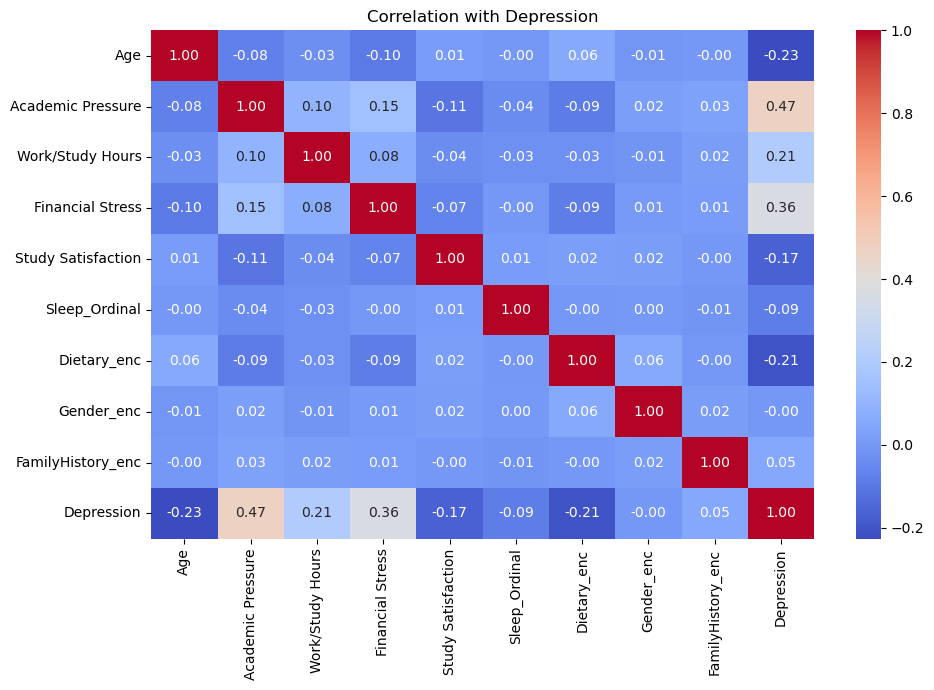

In [10]:
# Correlation heatmap (numeric + encoded columns only)
corr_cols = numeric_cols + ['Gender_enc', 'FamilyHistory_enc', 'Depression']
plt.figure(figsize=(10, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation with Depression')
plt.tight_layout()
plt.show()

### Interpretation

The heatmap highlights positive and negative relationships among variables.

Variables showing stronger relationships with depression may be particularly important during model training.

# 8. Preparing Data for Machine Learning

The dataset is divided into:

- Predictor variables (Features)
- Target variable (Depression)

These variables will be used to train and evaluate machine learning models.

In [11]:
features = ['Gender_enc', 'Age', 'Academic Pressure', 'Sleep_Ordinal', 'Dietary_enc',
            'Study Satisfaction', 'Work/Study Hours', 'Financial Stress', 'FamilyHistory_enc']

X = df[features]
y = df['Depression']

## Splitting the Dataset

To evaluate model performance fairly, the dataset is divided into training and testing subsets.

The training data is used to learn patterns, while the testing data measures how well the model performs on unseen observations.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(22320, 9) (5581, 9)


## Feature Scaling

Some machine learning algorithms perform better when numerical features are placed on a similar scale.

Standardization is applied before training the Logistic Regression model.

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9. Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

In [14]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_train)

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      2313
           1       0.81      0.82      0.81      3268

    accuracy                           0.78      5581
   macro avg       0.77      0.77      0.77      5581
weighted avg       0.78      0.78      0.78      5581

AUC: 0.8469168861435101


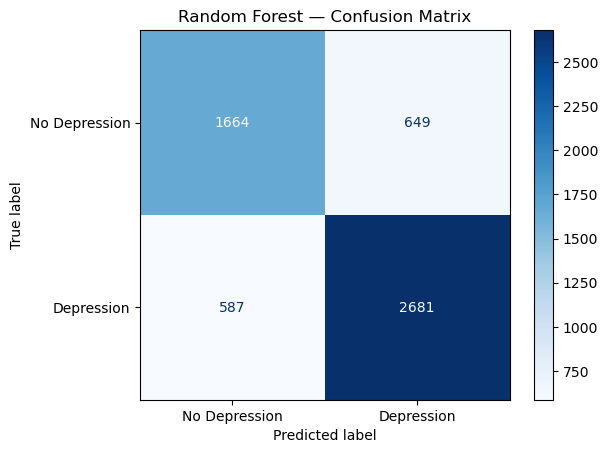

In [15]:
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))
rf_auc = roc_auc_score(y_test, rf_probs)
print("AUC:", rf_auc)

cm_rf = confusion_matrix(y_test, rf_preds)
ConfusionMatrixDisplay(cm_rf, display_labels=['No Depression', 'Depression']).plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.show()

### Interpretation

The Random Forest model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

The confusion matrix provides additional insight into classification performance.

## Feature Importance

One advantage of Random Forest is its ability to estimate how much each variable contributes to prediction.

Higher importance values indicate stronger influence on the model's decisions.

              Feature  Importance
2   Academic Pressure    0.227605
1                 Age    0.181055
6    Work/Study Hours    0.152423
7    Financial Stress    0.138938
5  Study Satisfaction    0.090745
3       Sleep_Ordinal    0.078640
4         Dietary_enc    0.056502
0          Gender_enc    0.038034
8   FamilyHistory_enc    0.036059


C:\Users\KHENNYG\AppData\Local\Temp\ipykernel_18424\297400040.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


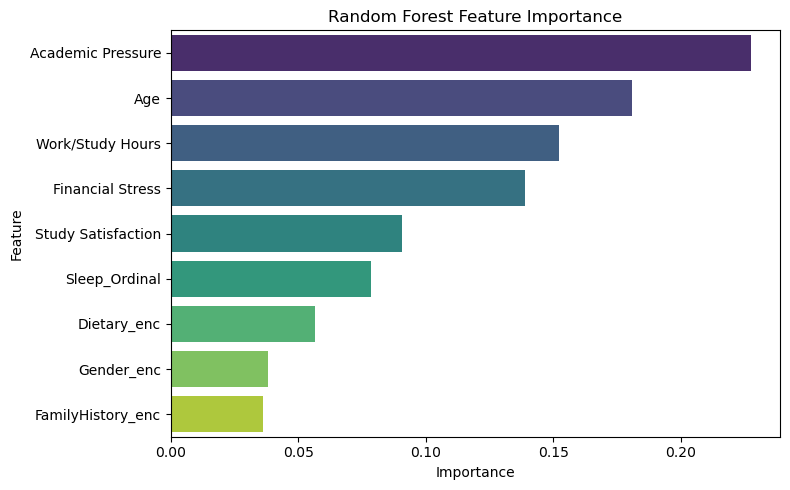

In [16]:
# Random Forest feature importance — which factors it leaned on most
importance_df = pd.DataFrame({'Feature': features, 'Importance': rf_model.feature_importances_})
importance_df = importance_df.sort_values('Importance', ascending=False)
print(importance_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

# 10. Logistic Regression Model

Logistic Regression is a statistical classification algorithm commonly used for binary prediction problems.

It estimates the probability that a student belongs to either the depression or non-depression class.

In [17]:
log_model = LogisticRegression(max_iter=1000).fit(X_train_scaled, y_train)

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.77      0.72      0.74      2313
           1       0.81      0.85      0.83      3268

    accuracy                           0.80      5581
   macro avg       0.79      0.78      0.79      5581
weighted avg       0.79      0.80      0.79      5581

AUC: 0.8658399176386355


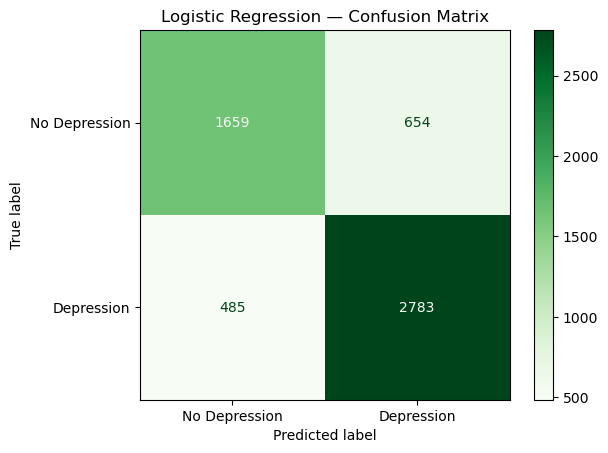

In [18]:
log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, log_preds))
log_auc = roc_auc_score(y_test, log_probs)
print("AUC:", log_auc)

cm_log = confusion_matrix(y_test, log_preds)
ConfusionMatrixDisplay(cm_log, display_labels=['No Depression', 'Depression']).plot(cmap='Greens')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

### Interpretation

The Logistic Regression model is evaluated using the same performance metrics as Random Forest, allowing for an objective comparison.

## Model Interpretation

Unlike Random Forest, Logistic Regression provides coefficients that indicate whether each variable increases or decreases the likelihood of depression.

              Feature  Coefficient
2   Academic Pressure     1.170606
7    Financial Stress     0.830835
6    Work/Study Hours     0.443073
8   FamilyHistory_enc     0.132988
0          Gender_enc    -0.001607
3       Sleep_Ordinal    -0.218534
5  Study Satisfaction    -0.312923
4         Dietary_enc    -0.430190
1                 Age    -0.519046


C:\Users\KHENNYG\AppData\Local\Temp\ipykernel_18424\3593509168.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')


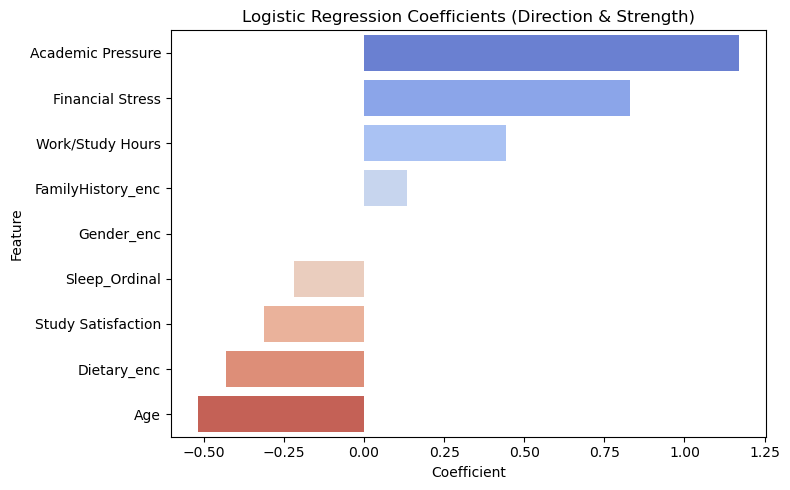

In [19]:
# Logistic Regression coefficients — direction and relative strength of each factor
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': log_model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print(coef_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Logistic Regression Coefficients (Direction & Strength)')
plt.tight_layout()
plt.show()

# 11. Comparing Model Performance

The performance of both models is compared using several evaluation metrics.

This comparison helps identify the model best suited for deployment.

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'],
    'Random Forest': [
        accuracy_score(y_test, rf_preds),
        precision_score(y_test, rf_preds),
        recall_score(y_test, rf_preds),
        f1_score(y_test, rf_preds),
        rf_auc
    ],
    'Logistic Regression': [
        accuracy_score(y_test, log_preds),
        precision_score(y_test, log_preds),
        recall_score(y_test, log_preds),
        f1_score(y_test, log_preds),
        log_auc
    ]
})
comparison['Better Model'] = np.where(
    comparison['Random Forest'] > comparison['Logistic Regression'], 'Random Forest', 'Logistic Regression'
)
print(comparison)

      Metric  Random Forest  Logistic Regression         Better Model
0   Accuracy       0.778534             0.795915  Logistic Regression
1  Precision       0.805105             0.809718  Logistic Regression
2     Recall       0.820379             0.851591  Logistic Regression
3   F1-score       0.812671             0.830127  Logistic Regression
4        AUC       0.846917             0.865840  Logistic Regression


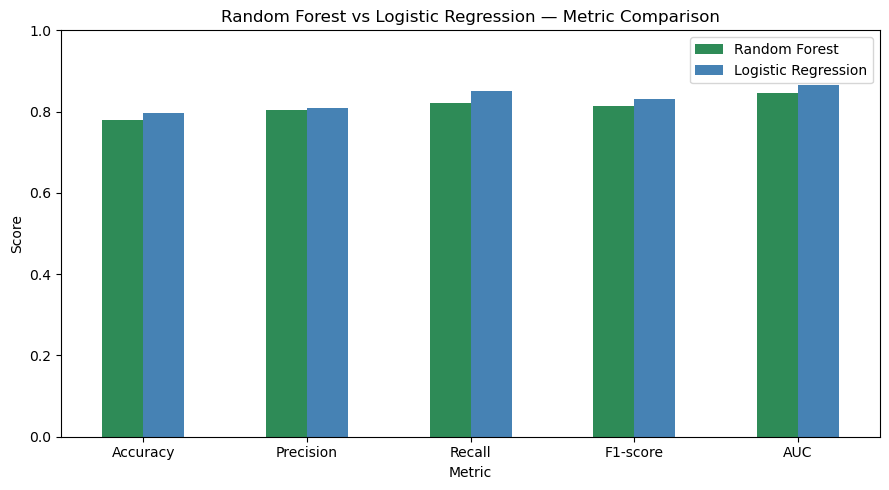

In [21]:
# Visual side-by-side
comparison.set_index('Metric')[['Random Forest', 'Logistic Regression']].plot(
    kind='bar', figsize=(9, 5), color=['seagreen', 'steelblue']
)
plt.title('Random Forest vs Logistic Regression — Metric Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Summary

Visual comparisons make it easier to identify differences in model performance and communicate findings to non-technical audiences.m

# 12. Risk Classification System

Predicted probabilities are converted into meaningful risk categories.

This allows users to interpret model predictions more easily than raw percentages alone.

In [22]:
def risk_label(p):
    if p < 30:
        return 'Low Risk', 'Green'
    elif p < 60:
        return 'Moderate Risk', 'Amber'
    elif p < 80:
        return 'High Risk', 'Orange'
    else:
        return 'Critical', 'Red'

# 13. Interactive Student Risk Prediction Tool

To demonstrate practical application, an interactive prediction system has been developed.

Users provide student information, and the trained models estimate depression risk.

Each assessment is automatically stored for future reference.

In [23]:
import os

RECORDS_FILE = 'student_records.csv'

def get_next_id():
    if not os.path.exists(RECORDS_FILE):
        return "STU-0001"
    existing = pd.read_csv(RECORDS_FILE)
    if existing.empty:
        return "STU-0001"
    last_num = existing['StudentID'].str.extract(r'(\d+)').astype(int).max()[0]
    return f"STU-{last_num + 1:04d}"

def add_student_interactive():
    """Prompts a non-technical user for plain-language answers, then predicts and saves the record."""
    print("=== New Student Risk Assessment ===")
    gender = input("Gender (Male/Female): ")
    age = float(input("Age: "))
    academic_pressure = float(input("Academic Pressure (1-5 scale): "))
    sleep_duration = input("Sleep Duration (Less than 5 hours / 5-6 hours / 7-8 hours / More than 8 hours): ")
    dietary_habits = input("Dietary Habits (Unhealthy / Moderate / Healthy): ")
    study_satisfaction = float(input("Study Satisfaction (1-5 scale): "))
    work_study_hours = float(input("Work/Study Hours per day: "))
    financial_stress = float(input("Financial Stress (1-5 scale): "))
    family_history = input("Family History of Mental Illness (Yes/No): ")

    return add_student_record(gender, age, academic_pressure, sleep_duration, dietary_habits,
                               study_satisfaction, work_study_hours, financial_stress, family_history)

def add_student_record(gender, age, academic_pressure, sleep_duration, dietary_habits,
                        study_satisfaction, work_study_hours, financial_stress, family_history):
    """Encodes the plain-language inputs, runs both models, saves the record, returns the result."""
    gender_enc = 1 if gender.strip().lower() == 'female' else 0
    family_enc = 1 if family_history.strip().lower() == 'yes' else 0

    sleep_lookup = {'less than 5 hours': 1, '5-6 hours': 2, '7-8 hours': 3, 'more than 8 hours': 4}
    diet_lookup = {'unhealthy': 1, 'moderate': 2, 'healthy': 3}
    sleep_val = sleep_lookup.get(sleep_duration.strip().lower(), 2)
    diet_val = diet_lookup.get(dietary_habits.strip().lower(), 2)

    row = pd.DataFrame([{
        'Gender_enc': gender_enc, 'Age': age, 'Academic Pressure': academic_pressure,
        'Sleep_Ordinal': sleep_val, 'Dietary_enc': diet_val,
        'Study Satisfaction': study_satisfaction, 'Work/Study Hours': work_study_hours,
        'Financial Stress': financial_stress, 'FamilyHistory_enc': family_enc
    }])[features]

    rf_prob = rf_model.predict_proba(row)[0][1] * 100
    log_prob = log_model.predict_proba(scaler.transform(row))[0][1] * 100
    avg_prob = (rf_prob + log_prob) / 2
    label, color = risk_label(avg_prob)

    student_id = get_next_id()
    record = row.copy()
    record.insert(0, 'StudentID', student_id)
    record['RF_Risk%'] = round(rf_prob, 1)
    record['LogReg_Risk%'] = round(log_prob, 1)
    record['Avg_Risk%'] = round(avg_prob, 1)
    record['RiskLabel'] = label
    record['RiskColor'] = color

    header_needed = not os.path.exists(RECORDS_FILE)
    record.to_csv(RECORDS_FILE, mode='a', header=header_needed, index=False)

    print(f"\nSaved as {student_id}")
    print(f"Random Forest Risk:      {rf_prob:.1f}%")
    print(f"Logistic Regression Risk: {log_prob:.1f}%")
    print(f"Average Risk Score:       {avg_prob:.1f}%  |  {label}  ({color})")

    return student_id, avg_prob, label, color

In [ ]:
add_student_interactive()

=== New Student Risk Assessment ===


In [ ]:
def get_prediction_by_id(student_id):
    if not os.path.exists(RECORDS_FILE):
        print("No records saved yet.")
        return None
    records = pd.read_csv(RECORDS_FILE)
    match = records[records['StudentID'] == student_id]
    if match.empty:
        print(f"No record found for {student_id}")
        return None
    return match.iloc[0]

get_prediction_by_id("STU-0002")

In [ ]:
pd.read_csv(RECORDS_FILE)

# 14. Conclusion

This project successfully developed and evaluated machine learning models capable of predicting depression risk among students.

Following data cleaning, feature engineering, statistical analysis, and predictive modelling, both Random Forest and Logistic Regression produced strong classification performance.

The interactive prediction tool demonstrates how these models can support early identification of at-risk students and potentially assist educational institutions in making informed intervention decisions.

---

# Recommendations

- Collect additional behavioural and psychological variables to improve predictive performance.
- Perform hyperparameter tuning to further optimise the models.
- Evaluate additional algorithms such as XGBoost or LightGBM.
- Deploy the prediction system as a web application using Streamlit or Flask.
- Retrain the models periodically as new data becomes available.